# Mandatory Assignment FIE463 S26

*Disclaimer: The coding assistant Finn in Sikt was used to foolproof my code, help my initial ideas to be more effective, and to make sure the assignment answered all questions needed. The code and text produced is my own.* 

In [1]:
# Imports of numpy and matplotlib, used in the assignment
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# Parameters used throughout the assignment
Rf = 1.0 # Risk-free return
w = 1.0 # Initial wealth
beta = 0.9 # Discount factor
mu = 0.04 # Mean return of the risky asset
sigma = 0.16 # Standard deviation of the risky asset
gamma = 4.0 # Risk aversion

# Etas with probabilities
etas = np.array([-np.sqrt(3), 0.0, np.sqrt(3)]) # Possible outcomes for the standard normal variable
probs = np.array([1/6, 2/3, 1/6]) # Probabilities for each outcome

## Task 1:

In [3]:
# Risk returns
R = Rf + mu + sigma * etas

# Computing expected return, the variance of returns, risk premium, and Sharpe ratio
ER = np.sum(probs * R) # Expected return
VarR = np.sum(probs * (R - ER)**2) # Variance of returns
stdR = np.sqrt(VarR) # Standard deviation of returns

risk_premium = ER - Rf # Risk premium
sharpe_ratio = risk_premium / np.sqrt(VarR) # Sharpe ratio

results_task1 = {
    "Expected Return E[R]": float(ER),
    "Variance Var(R)": float(VarR),
    "Risk Premium E[R]-Rf": float(risk_premium),
    "Sharpe Ratio": float(sharpe_ratio)
}
results_task1

{'Expected Return E[R]': 1.04,
 'Variance Var(R)': 0.0256,
 'Risk Premium E[R]-Rf': 0.040000000000000036,
 'Sharpe Ratio': 0.2500000000000002}

I compute the expected gross risky return, its variance, the risk premium, and the Sharpe ratio using the discretized return distribution.

The results show that the mean excess return is close to μ and the variance is close to σ², so the discretization matches the intended normal distribution well.

## Task 2

In [4]:
# Utility function for CARA preferences
def util(c, gamma):
    return -np.exp(-gamma * c) # np.exp is vectorized, so c can be a scalar or an array

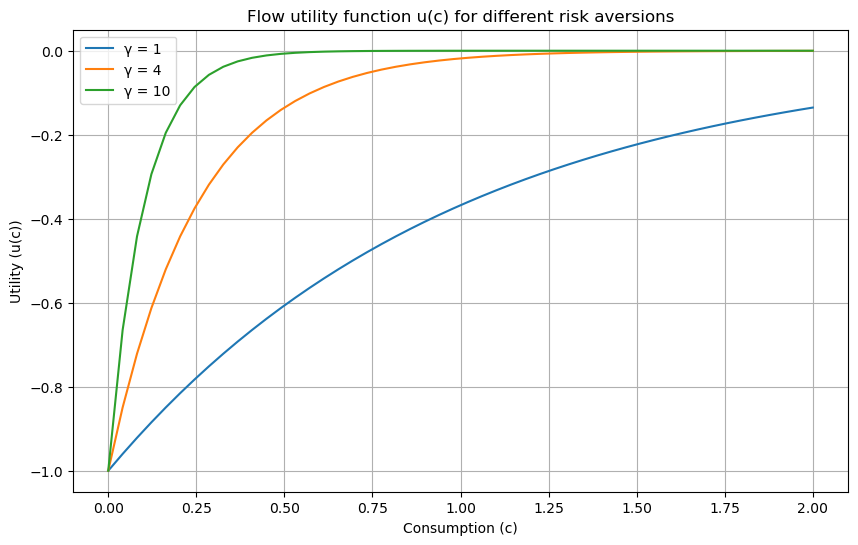

In [5]:
# Plot u(c) for c in [0,2] and gamma in {1,4,10}
c_values = np.linspace(0, 2) # Consumption values from 0 to 2
gammas = [1, 4, 10] # Risk aversion coefficients


plt.figure(figsize=(10, 6))
for g in gammas:
    u_values = util(c_values, g) # Compute utility values for each consumption level
    plt.plot(c_values, u_values, label=f'γ = {g}') # Plot the utility function


plt.title('Flow utility function u(c) for different risk aversions')
plt.xlabel('Consumption (c)')
plt.ylabel('Utility (u(c))')
plt.legend()
plt.grid()
plt.show()


I define a function `util(c, gamma)` that evaluates CARA flow utility:

u(c) = -exp(-γc).

I then plot the utility function for consumption values between 0 and 2 for γ = 1, 4, and 10.

The plot shows that higher γ makes the utility function more curved, meaning the investor becomes more risk averse.

## Task 3

In [6]:
# Function to compute expected utility given savings s and risky share alpha
def expected_util(s, alpha, beta, gamma, sigma, mu, w, etas, probs):
    s = np.asarray(s) # Ensure s is a numpy array for vectorized operations
    alpha = np.asarray(alpha) # Ensure alpha is a numpy array for vectorized operations

    c1 = w - s # Consumption in period 1

    R = Rf + mu + sigma * etas # Risky returns for each state
    R = R.reshape((R.size,) + (1,) * s.ndim) # Reshape R for broadcasting with s and alpha

    probs_ = probs.reshape((probs.size,) + (1,) * s.ndim) # Reshape probabilities for broadcasting

    c2 = R * alpha * s + Rf * (1 - alpha) * s # Consumption in period 2 for each state

    EU = util(c1, gamma) + beta * np.sum(probs_ * util(c2, gamma), axis=0) # Expected utility across states

    return EU

In [7]:
# Example usage of expected_util function to see whether it works. 
s = 0.8 # Example savings level
alpha = 0.2 # Example portfolio share in the risky asset

float(expected_util(s, alpha, beta, gamma, sigma, mu, w, etas, probs)) # Compute expected utility for the given parameters


-0.4852756766248212

I define a function `expected_util()` that computes expected lifetime utility for given savings s and risky share α.

The function calculates period 1 consumption and expected utility from period 2 consumption across the three return states.

A test evaluation returns a single scalar value, confirming that the function works as intended.

## Task 4

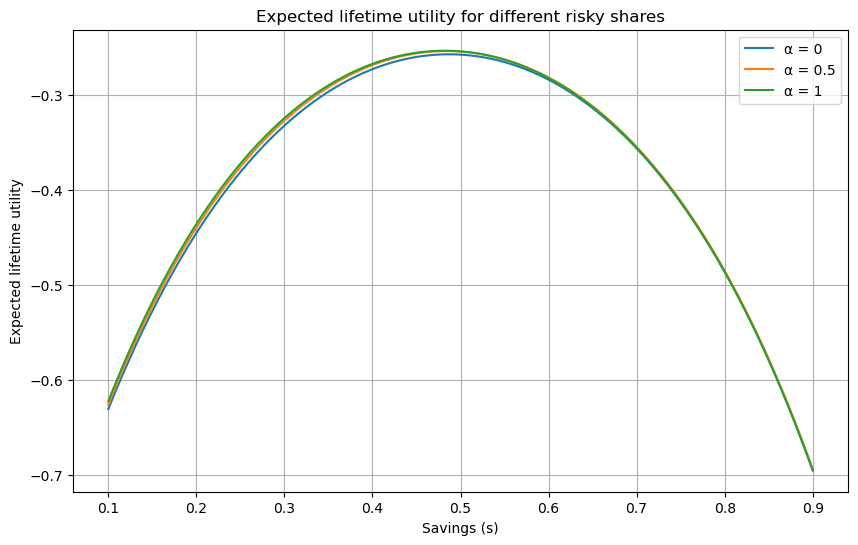

In [8]:
# Savings grid (200 points)
s_grid = np.linspace(0.1, w - 0.1, 200)

# Three portfolio shares
alphas = [0, 0.5, 1]

# Plot
plt.figure(figsize=(10, 6))

for a in alphas:
    U_vals = expected_util(s_grid, a, beta, gamma, sigma, mu, w, etas, probs) 
    plt.plot(s_grid, U_vals, label=f"α = {a}")

plt.title("Expected lifetime utility for different risky shares")
plt.xlabel("Savings (s)")
plt.ylabel("Expected lifetime utility")
plt.legend()
plt.grid()
plt.show()

I evaluate expected lifetime utility on a grid of 200 savings values for α = 0, 0.5, and 1.

I plot the resulting utility curves in one figure to visualize how utility depends on savings for different risky shares.

The curves are hump-shaped, meaning utility is maximized at an interior savings level because saving too little or too much reduces consumption in one of the periods.

## Task 5 and 6

In [9]:
# Function to find the optimal savings and risky share that maximize expected utility
def find_optimum(beta, gamma, sigma, mu, w, etas, probs):
    s_grid = np.linspace(1e-6, w - 1e-6, 1000) # Savings grid with 1000 points
    alpha_grid = np.linspace(0.0, 1.0, 1000) # Risky share grid with 1000 points

    S, A = np.meshgrid(s_grid, alpha_grid, indexing="ij") # Create a grid of savings and risky shares

    U = expected_util(S, A, beta, gamma, sigma, mu, w, etas, probs)

    idx = np.argmax(U) # Find the index of the maximum expected utility
    i, j = np.unravel_index(idx, U.shape) # Convert the index to 2D indices for savings and risky share

    s_star = S[i, j] # Optimal savings corresponding to the maximum expected utility
    alpha_star = A[i, j] # Optimal risky share corresponding to the maximum expected utility
    U_max = U[i, j] # Maximum expected utility

    return s_star, alpha_star, U_max

In [10]:
s_star, alpha_star, U_max = find_optimum(beta, gamma, sigma, mu, w, etas, probs)

results_task56 = {
    "Optimal savings (s*)": float(s_star),
    "Optimal risky share (α*)": float(alpha_star),
    "Maximum expected utility (U_max)": float(U_max)
}

results_task56



{'Optimal savings (s*)': 0.4824825175175174,
 'Optimal risky share (α*)': 0.8098098098098098,
 'Maximum expected utility (U_max)': -0.25279977091370276}

I solve the investor’s problem using grid search.

I evaluate expected lifetime utility over 1000 candidate values for savings s and 1000 values for the risky share α, and locate the combination that maximizes utility.

The optimal choices (s*, α*) and the maximized expected utility are reported below.

## Task 7

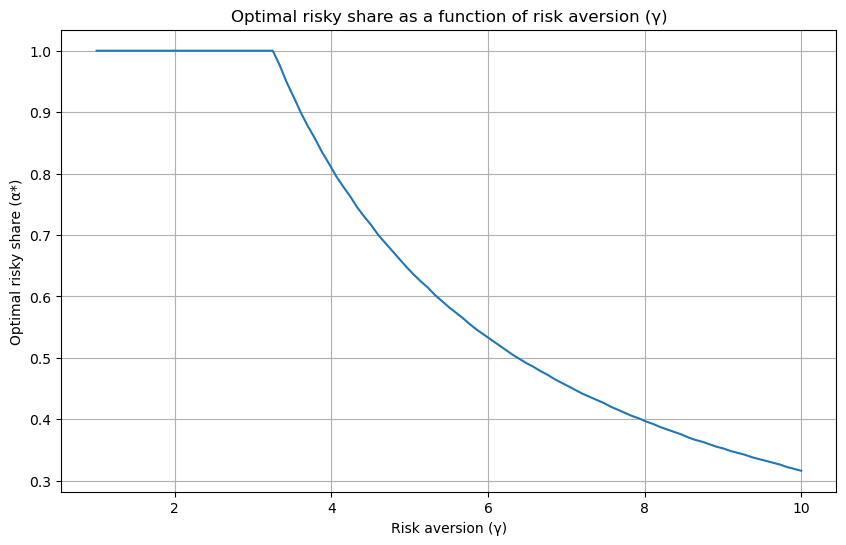

In [11]:
gamma_grid = np.linspace(1, 10, 101) # Grid of gamma values from 1 to 10 with 101 points
alpha_star_grid = np.empty_like(gamma_grid) # Array to store optimal risky shares for each gamma

for i, g in enumerate(gamma_grid):
    _, a_star, _ = find_optimum(beta, g, sigma, mu, w, etas, probs) # underscore is used to ignore the optimal savings and maximum expected utility, we only care about the optimal risky share
    alpha_star_grid[i] = a_star

plt.figure(figsize=(10, 6))
plt.plot(gamma_grid, alpha_star_grid)
plt.title("Optimal risky share as a function of risk aversion (γ)")
plt.xlabel("Risk aversion (γ)")
plt.ylabel("Optimal risky share (α*)")
plt.grid()
plt.show()

I compute the optimal risky share α* for 101 values of γ between 1 and 10.

The plot shows that α* decreases as risk aversion increases, since more risk-averse investors choose to invest less in the risky asset.

## Task 8

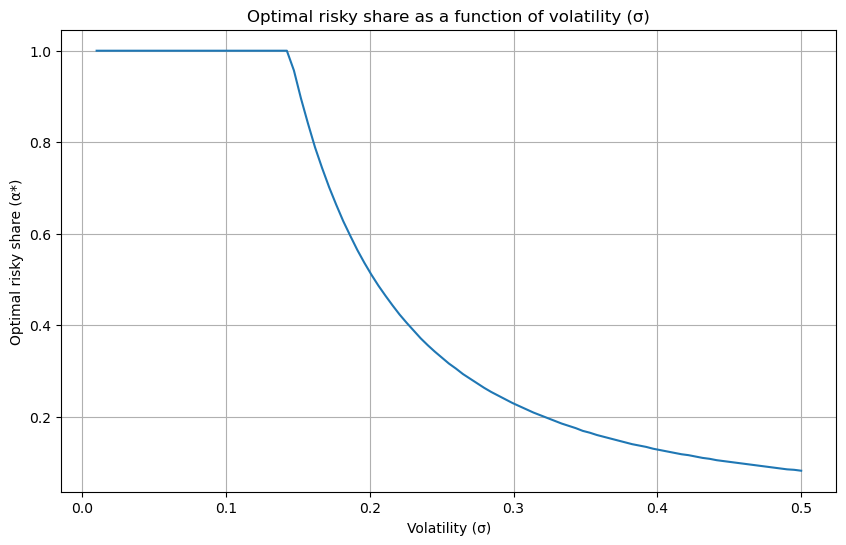

In [12]:
sigma_grid = np.linspace(0.01, 0.5, 101)
alpha_star_sigma = np.empty_like(sigma_grid)

for i, sig in enumerate(sigma_grid):
    _, a_star, _ = find_optimum(beta, gamma, sig, mu, w, etas, probs)
    alpha_star_sigma[i] = a_star

plt.figure(figsize=(10, 6))
plt.plot(sigma_grid, alpha_star_sigma)
plt.title("Optimal risky share as a function of volatility (σ)")
plt.xlabel("Volatility (σ)")
plt.ylabel("Optimal risky share (α*)")
plt.grid()
plt.show()

I compute the optimal risky share α* for 101 values of σ between 0.01 and 0.5.

The plot shows that α* decreases as volatility increases, since higher uncertainty makes the risky asset less attractive.